In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist #https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------
# Load dataset
# ---------------------------------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


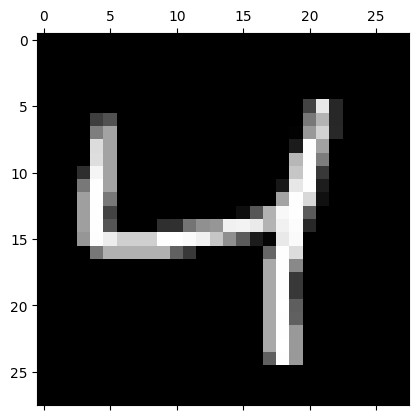

In [ ]:
plt.matshow(X_train[2], cmap='gray')

In [ ]:
X_train[2]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  67, 232,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  62,  81,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 120, 180,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 126, 163,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   2, 153, 210,  40,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 220, 163,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,  27, 254, 162,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 222, 163,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0, 183, 254, 125,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,  46, 245, 163,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0, 198, 254,  56,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 120, 254, 163,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,  23, 231, 254,  29,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 159, 254, 120,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0, 163, 254, 216,  16,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 159, 254,  67,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  14,  86, 178, 248, 254,  91,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 159, 254,  85,   0,   0,   0,  47,  49, 116, 144,
        150, 241, 243, 234, 179, 241, 252,  40,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 150, 253, 237, 207, 207, 207, 253, 254, 250, 240,
        198, 143,  91,  28,   5, 233, 250,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 119, 177, 177, 177, 177, 177,  98,  56,   0,
          0,   0,   0,   0, 102, 254, 220,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 169, 254, 137,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 169, 254,  57,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 169, 254,  57,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 169, 255,  94,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 169, 254,  96,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 169, 254, 153,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 169, 255, 153,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [ ]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_train_flattened[2]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,  67, 232,  39,   0,   0,   0,   0,   0,   0,
         0,   0,   0,  62,  81,   0,   0,   0,   0,   0,   0,   

In [ ]:

# ---------------------------------------------------
# Normalize pixel values
# ---------------------------------------------------
X_train = X_train / 255.0
X_test  = X_test / 255.0

# ---------------------------------------------------
# Build model
# ---------------------------------------------------
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ---------------------------------------------------
# Train model
# ---------------------------------------------------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)


# ---------------------------------------------------
#5. Predictions
# ---------------------------------------------------
y_prob = model.predict(X_test)
y_prob

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[7.2230546e-12, 3.2637248e-12, 6.6268615e-07, ..., 9.9999481e-01,
        7.4200677e-13, 2.2449937e-08],
       [8.7001136e-18, 4.7574966e-10, 9.9999994e-01, ..., 1.5165044e-16,
        2.1141425e-08, 1.5493179e-26],
       [1.4326493e-08, 9.9958235e-01, 2.2940901e-06, ..., 4.0460311e-04,
        7.8701696e-06, 2.3807311e-06],
       ...,
       [1.3655504e-15, 9.2911985e-13, 2.1776673e-17, ..., 1.6647437e-09,
        1.0384143e-11, 6.4780600e-08],
       [4.0828640e-16, 1.0545335e-19, 1.0125284e-16, ..., 1.3932368e-13,
        5.3187559e-12, 4.9636872e-17],
       [6.5884013e-12, 9.5250598e-13, 9.4270479e-16, ..., 2.4923854e-19,
        6.4293202e-14, 7.4732789e-14]], dtype=float32)

In [ ]:
y_prob.shape

(10000, 10)

In [ ]:
y_prob[2]

array([1.4326493e-08, 9.9958235e-01, 2.2940901e-06, 2.9931635e-07,
       6.9427642e-08, 1.7666994e-07, 5.2355853e-09, 4.0460311e-04,
       7.8701696e-06, 2.3807311e-06], dtype=float32)

In [ ]:
y_pred = np.argmax(y_prob, axis=1)
y_pred

array([7, 2, 1, ..., 4, 5, 6])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9731 - loss: 0.1260
Test accuracy: 0.9764000177383423
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Confusion Matrix
[[ 966    0    4    0    0    1    4    1    3    1]
 [   0 1126    3    3    0    0    1    0    2    0]
 [   2    0 1021    4    0    0    1    2    2    0]
 [   0    0    5  992    0    6    0    3    4    0]
 [   1    1    3    1  961    0    3    2    1    9]
 [   1    0    0   13    0  871    1    0    5    1]
 [   5    3    1    1    3    8  937    0    0    0]
 [   3    4   18    6    2    1    0  986    2    6]
 [   1    1    5   10    0    5    0    3  943    6]
 [   4    2    2    9   14    9    0    4    4  961]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.99      0.98      1032
           3       0.95      0.98      0.97      1010
       

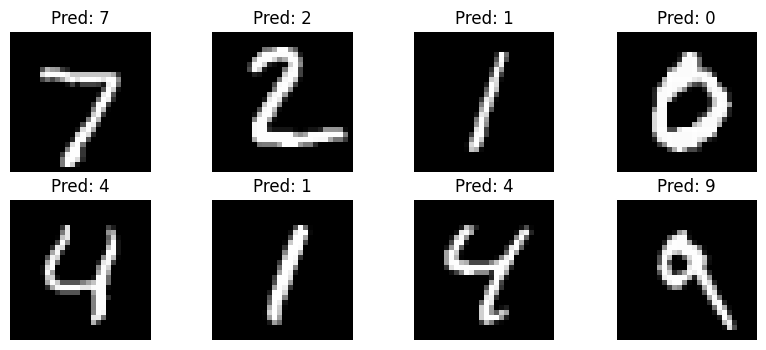

In [ ]:
# ---------------------------------------------------
# Evaluate model
# ---------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)

# ---------------------------------------------------
# Predictions
# ---------------------------------------------------
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------
# Show predictions
# ---------------------------------------------------
plt.figure(figsize=(10,4))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.show()